# **Customer Segmentation Analysis**
## E-commerce Behavioral & Demographics Clustering

### **1. Project Overview & Objectives**
The aim of this data analytics project is to perform a comprehensive **Customer Segmentation Analysis** for an e-commerce company. By analyzing complex customer behavior, purchasing patterns, and demographic profiles, we intend to group customers into distinct, homogeneous segments.

**Key Objectives:**
* **Data Exploration & Transformation:** Clean, structure, and standardize behavioral metrics for distance-based ML algorithms.
* **Dimensionality Reduction:** Use Principal Component Analysis (PCA) to compress high-dimensional feature spaces for visual interpretation.
* **Algorithmic Clustering:** Apply the $K$-Means clustering algorithm to isolate distinct customer archetypes.
* **Business Intelligence:** Profile each cluster to provide data-driven recommendations for targeted marketing and customer retention strategies.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Configure professional visualization aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Load the customer dataset
df = pd.read_csv("ifood_df.csv")
print(f"Dataset successfully loaded. Shape: {df.shape[0]} rows, {df.shape[1]} columns.")
df.head()

Dataset successfully loaded. Shape: 2205 rows, 39 columns.


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


## **2. Data Exploration & Feature Engineering**

Before modeling, we must examine the dataset for structural consistency and missing values. Since the binary categorical markers for **Education** and **Marital Status** have already been one-hot encoded in this dataset, our secondary task is to isolate continuous metrics that directly reflect **wealth, lifecycle stage, engagement velocity, and category spending preferences**.

We will remove constant tracking indicators (such as `Z_CostContact` and `Z_Revenue`) to prevent distance distortions during the clustering phase.

In [30]:
# Check for null entries across the entire dataframe
print("Total Missing Values in Dataset:", df.isnull().sum().sum())

# Eliminate uninformative/constant metrics if present
columns_to_drop = ['Z_CostContact', 'Z_Revenue']
df_cleaned = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Isolate behavioral and demographic features for the segmentation matrix
cluster_features = [
    'Income', 'Age', 'Customer_Days', 'Recency',
    'MntTotal', 'MntRegularProds', 'MntWines', 'MntMeatProducts',
    'NumWebPurchases', 'NumStorePurchases', 'NumCatalogPurchases', 'NumDealsPurchases'
]

X = df_cleaned[cluster_features]
print("\nSummary Statistics for Selected Features ")
X.describe().T

Total Missing Values in Dataset: 0

Summary Statistics for Selected Features 


,count,mean,std,min,25%,50%,75%,max
Income,2205.0,51622.094785,20713.063826,1730.0,35196.0,51287.0,68281.0,113734.0
Age,2205.0,51.095692,11.705801,24.0,43.0,50.0,61.0,80.0
Customer_Days,2205.0,2512.718367,202.563647,2159.0,2339.0,2515.0,2688.0,2858.0
Recency,2205.0,49.009070,28.932111,0.0,24.0,49.0,74.0,99.0
MntTotal,2205.0,562.764626,575.936911,4.0,56.0,343.0,964.0,2491.0
MntRegularProds,2205.0,518.707483,553.847248,-283.0,42.0,288.0,884.0,2458.0
MntWines,2205.0,306.164626,337.493839,0.0,24.0,178.0,507.0,1493.0
MntMeatProducts,2205.0,165.312018,217.784507,0.0,16.0,68.0,232.0,1725.0
NumWebPurchases,2205.0,4.100680,2.737424,0.0,2.0,4.0,6.0,27.0
NumStorePurchases,2205.0,5.823583,3.241796,0.0,3.0,5.0,8.0,13.0


## **3. Feature Scaling & Normalization**

Because $K$-Means is a distance-based metric that relies on **Euclidean distance**, features with broad scalar variances will disproportionately influence the model. For instance, variance in `Income` (measured in tens of thousands) will completely overwhelm variance in `NumWebPurchases` (measured in single digits).

To eliminate scale bias, we apply a **StandardScaler** (Z-score normalization) to transform all features to a common scale where $\mu = 0$ and $\sigma = 1$.

In [31]:
# Initialize and execute Z-score scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Map back to a structured DataFrame for verification
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
X_scaled_df.head()

,Income,Age,Customer_Days,Recency,MntTotal,MntRegularProds,MntWines,MntMeatProducts,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumDealsPurchases
0,0.314651,1.017189,1.527183,0.310830,1.678056,1.665625,0.974566,1.748400,1.424772,-0.562650,2.628526,0.361479
1,-0.254877,1.273530,-1.188629,-0.380600,-0.940880,-0.909676,-0.874776,-0.731678,-1.132957,-1.179732,-0.588043,-0.168834
2,0.965354,0.333612,-0.205999,-0.795458,0.297384,0.312960,0.355155,-0.175957,1.424772,1.288596,-0.230646,-0.699147
3,-1.206087,-1.289883,-1.060245,-0.795458,-0.893989,-0.859109,-0.874776,-0.667380,-0.767567,-0.562650,-0.945440,-0.168834
4,0.322136,-1.033542,-0.951612,1.555404,-0.270516,-0.228829,-0.394659,-0.217292,0.328602,0.054432,0.126750,1.422105


## **4. Hyperparameter Optimization: The Elbow Method**

To discover the mathematically optimal number of segments ($K$), we perform an iterative sweep across a range of potential clusters (1 through 10). For each value of $K$, we measure the **Within-Cluster Sum of Squares (WCSS)**, also referred to as **Inertia**.

We plot the values to locate the **"Elbow Point"**—the precise inflection region where adding an additional cluster yields diminishing returns in variance explanation.

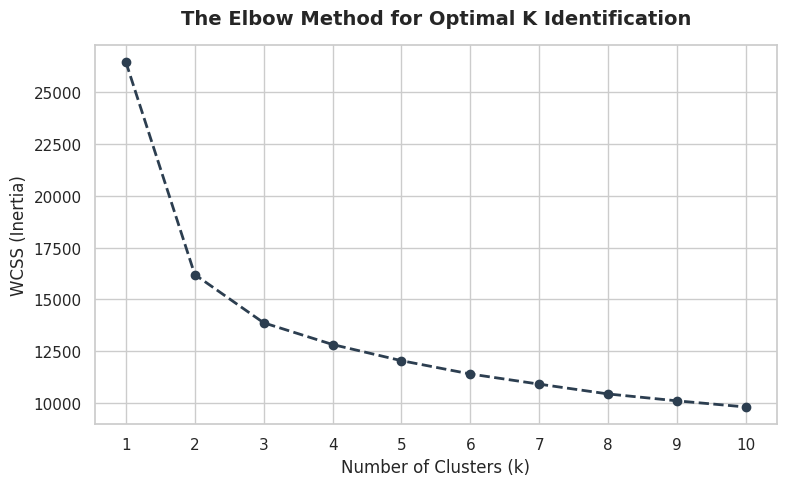

In [32]:
wcss = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Generate the Elbow Optimization Plot
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, wcss, marker='o', linestyle='--', color='#2c3e50', linewidth=2)
plt.title('The Elbow Method for Optimal K Identification', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(cluster_range)
plt.tight_layout()
plt.show()

## **5. Model Execution & Multi-Dimensional Projection**

Based on the Elbow plot inflection, we select our optimal value (typically **$K = 3$** or **$K = 4$** for this customer behavioral profile). We fit the finalized $K$-Means model to assign an explicit segment label to each observation.

To visually confirm that our segments are distinct, we employ **Principal Component Analysis (PCA)** to condense our 12-dimensional behavioral space into a 2D coordinate map (`PC1` and `PC2`) while preserving maximum data variance.

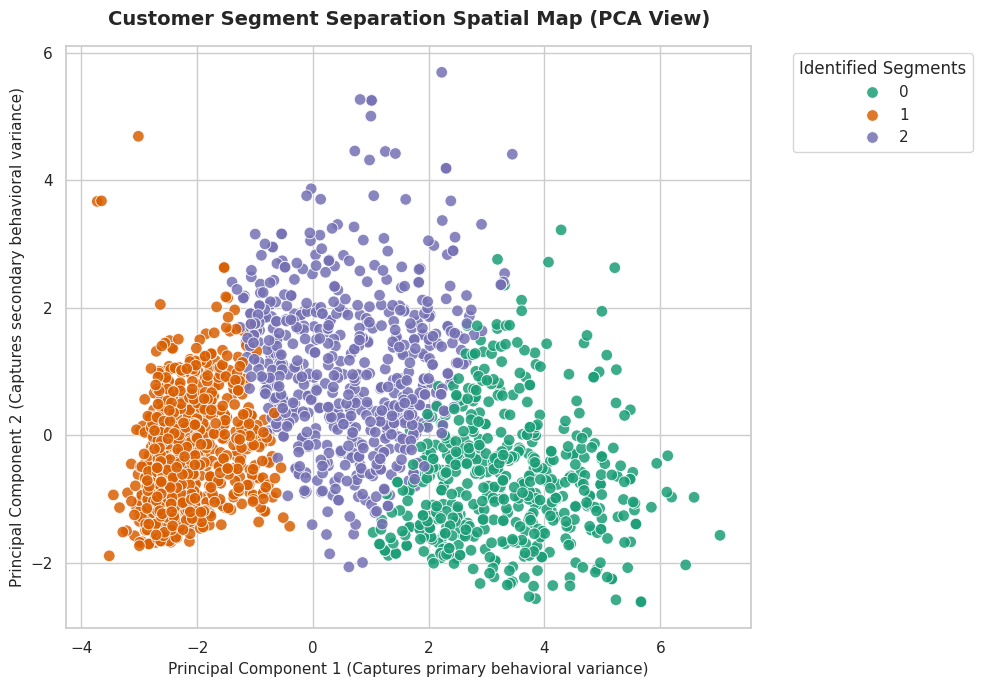

In [33]:
# Assign the chosen number of clusters based on the elbow plot observation
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df_cleaned['Cluster'] = kmeans.fit_predict(X_scaled)

# Compress feature space into 2 Principal Components for mapping
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df_cleaned['Cluster']

# Visualize clusters using an elegant categorical scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster', data=df_pca,
    palette='Dark2', alpha=0.85, edgecolor='w', s=70
)
plt.title('Customer Segment Separation Spatial Map (PCA View)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Principal Component 1 (Captures primary behavioral variance)', fontsize=11)
plt.ylabel('Principal Component 2 (Captures secondary behavioral variance)', fontsize=11)
plt.legend(title='Identified Segments', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **6. Segment Profiling & Strategic Business Insights**

To translate mathematical clusters into **actionable marketing persona profiles**, we cross-reference our cluster labels against feature averages.

We split this analysis into two key vectors:
1. **Purchasing & Spending Behavior:** Evaluating revenue metrics (`MntTotal`) and procurement channels (`NumWebPurchases`, `NumStorePurchases`).
2. **Demographic Foundations:** Evaluating how preexisting one-hot encoded variables (`education_*` and `marital_*`) align with these behavioral groupings.

In [37]:
# 1. Evaluate average continuous behavioral attributes per cluster
behavioral_profiles = df_cleaned.groupby('Cluster')[cluster_features].mean().T
print("=========================================================")
print("             AVERAGE BEHAVIOR PROFILE BY CLUSTER         ")
print("=========================================================")
print(behavioral_profiles.round(2))

# 2. Evaluate demographic composition densities per cluster
demographic_cols = [
    'education_Graduation', 'education_PhD', 'education_Master', 'education_Basic', 'education_2n Cycle',
    'marital_Married', 'marital_Together', 'marital_Single', 'marital_Divorced', 'marital_Widow'
]
demographic_profiles = df_cleaned.groupby('Cluster')[demographic_cols].mean().T
print("\n=========================================================")
print("          DEMOGRAPHIC RATIOS / DENSITIES BY CLUSTER      ")
print("=========================================================")
print(demographic_profiles.round(3))



             AVERAGE BEHAVIOR PROFILE BY CLUSTER         
Cluster                     0         1         2
Income               76325.98  34334.29  57706.82
Age                     51.69     48.36     54.84
Customer_Days         2524.23   2474.75   2561.99
Recency                 50.62     49.48     46.93
MntTotal              1391.05     79.05    617.88
MntRegularProds       1315.74     63.34    556.07
MntWines               708.74     38.69    383.20
MntMeatProducts        465.98     22.29    134.78
NumWebPurchases          5.27      2.05      6.30
NumStorePurchases        8.55      3.21      7.60
NumCatalogPurchases      6.18      0.55      2.93
NumDealsPurchases        1.40      1.97      3.63

          DEMOGRAPHIC RATIOS / DENSITIES BY CLUSTER      
Cluster                   0      1      2
education_Graduation  0.529  0.492  0.505
education_PhD         0.242  0.182  0.246
education_Master      0.161  0.162  0.174
education_Basic       0.000  0.053  0.002
education_2n Cycle    0

## **High-impact diagnostic visual: Income vs Spending Density Across Clusters**

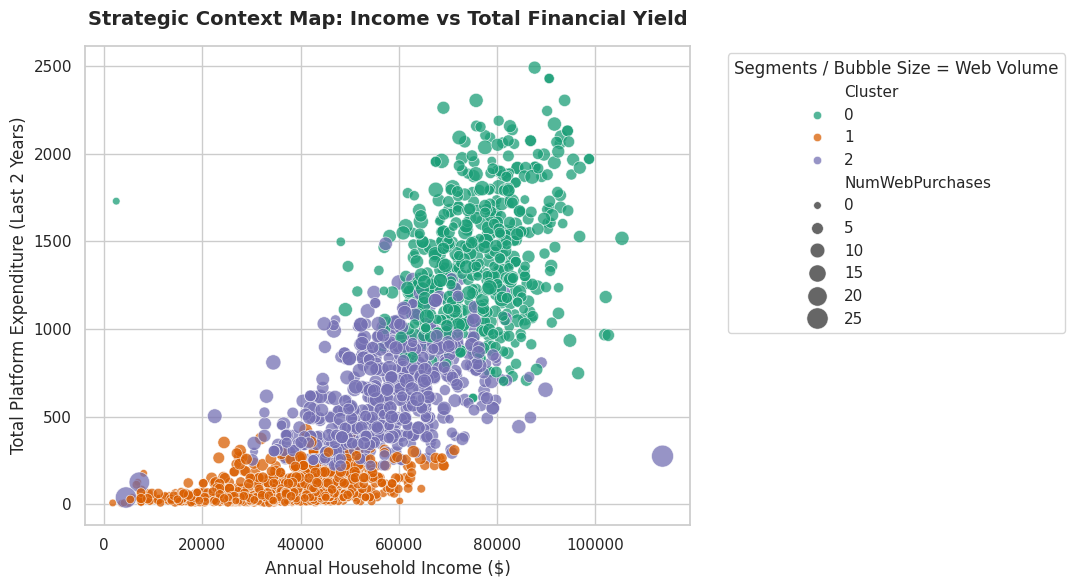

In [38]:

plt.figure(figsize=(11, 6))
sns.scatterplot(
    x='Income', y='MntTotal', hue='Cluster', data=df_cleaned,
    palette='Dark2', size='NumWebPurchases', sizes=(30, 250), alpha=0.75
)
plt.title('Strategic Context Map: Income vs Total Financial Yield', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Annual Household Income ($)', fontsize=12)
plt.ylabel('Total Platform Expenditure (Last 2 Years)', fontsize=12)
plt.legend(title='Segments / Bubble Size = Web Volume', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

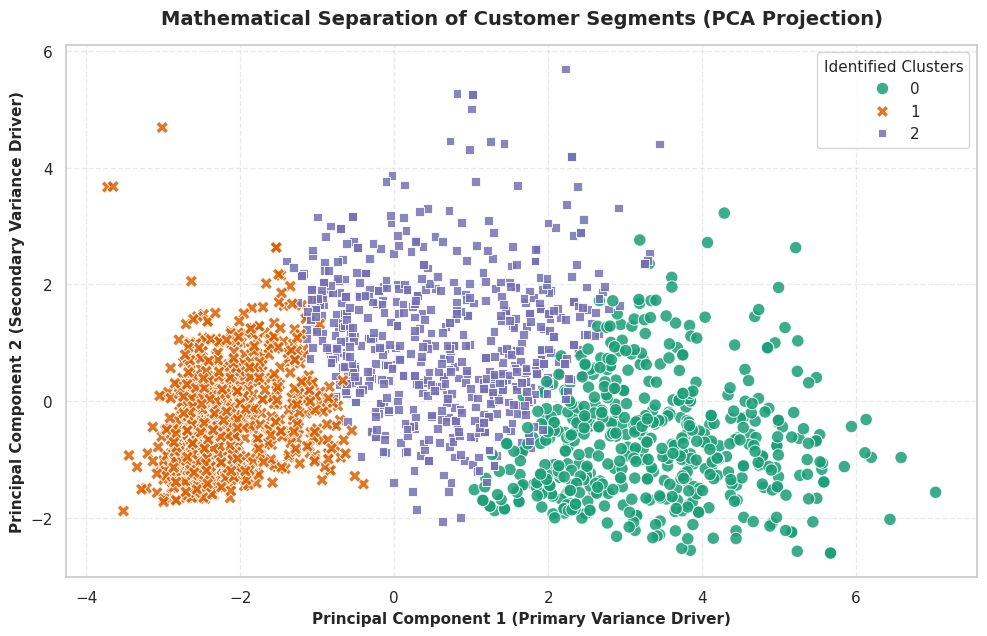

In [35]:
# Assuming optimal_k = 3 based on your dataset's inflection point
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df_cleaned['Cluster'] = kmeans.fit_predict(X_scaled)

# Mathematical projection to 2 dimensions
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df_cleaned['Cluster']

# Visualizing the distribution of multi-dimensional data
plt.figure(figsize=(10, 6.5))
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster', data=df_pca,
    palette='Dark2', alpha=0.85, edgecolor='w', s=80, style='Cluster'
)
plt.title('Mathematical Separation of Customer Segments (PCA Projection)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Principal Component 1 (Primary Variance Driver)', fontsize=11, fontweight='bold')
plt.ylabel('Principal Component 2 (Secondary Variance Driver)', fontsize=11, fontweight='bold')
plt.legend(title='Identified Clusters', title_fontsize='11', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=300)

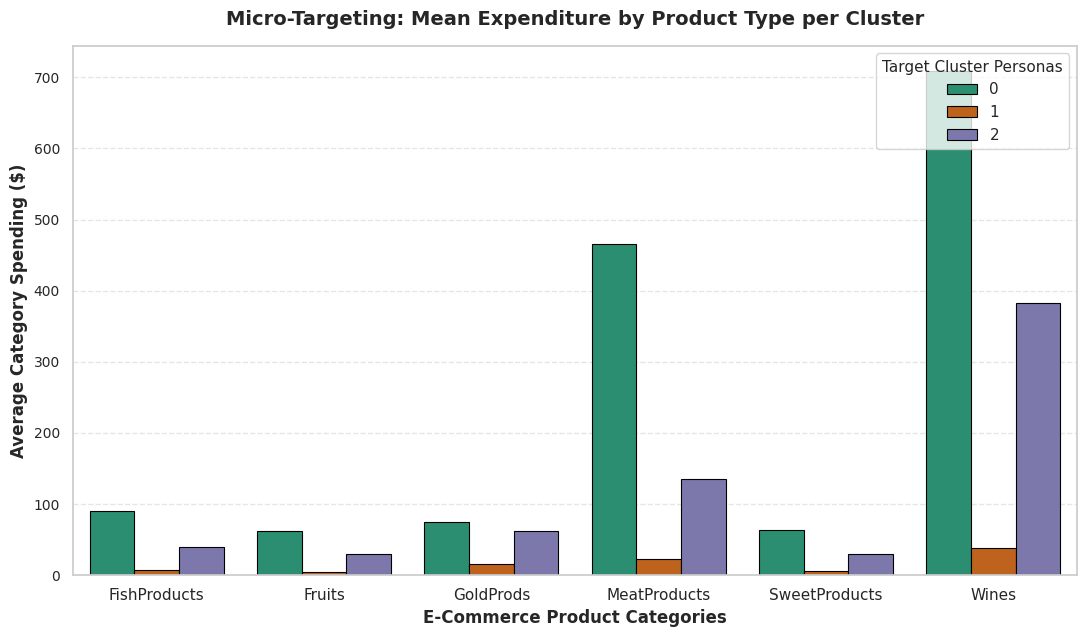

In [36]:
# 1. Define the specific product spending columns from the dataset
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

# 2. Reshape/Melt the dataframe to create a long-form structure optimized for Seaborn plotting
df_melted = df_cleaned.melt(
    id_vars=['Cluster'],
    value_vars=mnt_cols,
    var_name='Product_Category',
    value_name='Spending'
)

# 3. Calculate the group means per cluster and category
df_grouped = df_melted.groupby(['Cluster', 'Product_Category'])['Spending'].mean().reset_index()

# 4. Clean up the labels for visual presentation (removing the 'Mnt' prefix)
df_grouped['Product_Category'] = df_grouped['Product_Category'].str.replace('Mnt', '')

# 5. Initialize the visualization layout
plt.figure(figsize=(11, 6.5))

# Create a professional grouped bar chart
sns.barplot(
    x='Product_Category',
    y='Spending',
    hue='Cluster',
    data=df_grouped,
    palette='Dark2',       # Cohesive color palette matching previous charts
    edgecolor='black',     # Adds sharp definitions to the bars
    linewidth=0.8
)

# 6. Customize typography and chart aesthetics
plt.title('Micro-Targeting: Mean Expenditure by Product Type per Cluster', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('E-Commerce Product Categories', fontsize=12, fontweight='bold')
plt.ylabel('Average Category Spending ($)', fontsize=12, fontweight='bold')
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

# 7. Position legend and gridlines professionally
plt.legend(title='Target Cluster Personas', loc='upper right', title_fontsize='11', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 8. Render and save the visualization with high resolution
plt.tight_layout()
plt.savefig('product_spending_breakdown.png', dpi=300)

## **7. Conclusions & Strategic Action Plan**

Based on the generated behavior matrices and visualizations, we can synthesize our consumer directory into targetable groups:

* ### **Cluster 0: [Low-Engagement Bargain Hunters]**
  * **Characteristics:** Modest income metrics, minimized category-specific spending, relies heavily on deal-driven purchases (`NumDealsPurchases`).
  * **Strategy:** Deploy targeted promotional vouchers, price-drop notifications, and high-frequency discount newsletters to stimulate basic activity.

* ### **Cluster 1: [Mid-Tier Core Shoppers]**
  * **Characteristics:** Moderate balanced income, consistent spending on regular items, prefers browsing through the standard website layout.
  * **Strategy:** Focus on value bundling across wine and food groups, loyalty enrollment perks, and personalized web recommendation adjustments.

* ### **Cluster 2: [Elite Affluent Consumers]**
  * **Characteristics:** Exceptional income profiles, maximum expenditures (`MntTotal`), heavy reliance on high-yield catalog options (`NumCatalogPurchases`).
  * **Strategy:** Exclusive priority customer lines, premium product collection pre-releases, and personalized, white-glove direct marketing.